In [46]:
import pandas as pd
import seaborn as sns 
import matplotlib.pyplot as plt
import numpy as np 
import random 
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

In [2]:
regions = ["Asia", "EU", "NA"]
ranks = ["Iron", "Bronze", "Silver", "Gold", "Platinum", "Diamond", "Immortal", "Radiant"]
age_groups = ["16-20","21-25","26-30"]


In [3]:
skins = [
    {"skin_name": "RGX", "weapon": "Operator", "price": 2175},
    {"skin_name": "Ion", "weapon": "Bucky", "price": 1775},
    {"skin_name": "Prime", "weapon": "Guardian", "price": 1775},
    {"skin_name": "Oni", "weapon": "Bulldog", "price": 1775},
    {"skin_name": "Nocturnum", "weapon": "Marshal", "price": 2175},
    {"skin_name": "Evori", "weapon": "Melee", "price": 4950},
    {"skin_name": "Kuronami", "weapon": "Sheriff", "price": 2375},
    {"skin_name": "Araxys", "weapon": "Vandal", "price": 2175},
    {"skin_name": "Singularity", "weapon": "Ares", "price": 2175},
    {"skin_name": "Mystbloom", "weapon": "Outlaw", "price": 2175},
    {"skin_name": "Neptune", "weapon": "Odin", "price": 1775},
    {"skin_name": "Forsaken", "weapon": "Spectre", "price": 1775},
    {"skin_name": "Imperium", "weapon": "Judge", "price": 2175},
    {"skin_name": "Ora", "weapon": "Sheriff", "price": 2475},
    {"skin_name": "Gaia", "weapon": "Vandal", "price": 1775},
    {"skin_name": "Overdrive", "weapon": "Stinger", "price": 2175},
    {"skin_name": "Radiant", "weapon": "Ghost", "price": 2975},
    {"skin_name": "Elderflame", "weapon": "Frenzy", "price": 2475},
    {"skin_name": "Wasteland", "weapon": "Shorty", "price": 1275},
    {"skin_name": "Glitchpop", "weapon": "Classic", "price": 2175},
    {"skin_name": "Reaver", "weapon": "Bandit", "price": 1775},
    {"skin_name": "Spectrum", "weapon": "Phantom", "price": 2675}
]

In [4]:
data = [] #empty for now

In [5]:
n = 3000 #number of samples

for i in range(n):  
    skin = random.choice(skins)  
    discount = random.choice([0,10,20,30])   
    avg_spend = random.randint(500, 5000)  #customer's monthly spending capacity
    previous_purchases = random.randint(0,20) 
    wishlist = random.choice([0,1])
    event_active = random.choice ([0,1]) #special events running or not?
    
    final_price = skin["price"] * (1 - discount/100)
    
    
    prob = 0.1  # base probability (10% chance of buying)

    if wishlist == 1:
        prob += 0.25
    if discount >= 20:
        prob += 0.1
    if previous_purchases > 8:
        prob += 0.07
    if avg_spend > final_price:
        prob += 0.15
    
    purchase = np.random.rand() < prob #converts probability into actual 0/1 decision
        
        
        
    row = {
        "skin_name": skin["skin_name"],
        "weapon_type": skin["weapon"],
        "base_price_vp": skin["price"],
        "discount_percent": discount,
        "final_price_vp": final_price,
        "region": random.choice(regions),
        "rank": random.choice(ranks),
        "age_group": random.choice(age_groups),
        "avg_monthly_spend": avg_spend,
        "previous_purchases": previous_purchases,
        "wishlist_added": wishlist,
        "event_active": event_active,
        "purchased": purchase
    }
    
    data.append(row)
    

df = pd.DataFrame(data)
df.to_csv("valorant_store_dataset.csv", index = False)


In [6]:
df.head()

,skin_name,weapon_type,base_price_vp,discount_percent,final_price_vp,region,rank,age_group,avg_monthly_spend,previous_purchases,wishlist_added,event_active,purchased
0,Glitchpop,Classic,2175,30,1522.5,Asia,Diamond,21-25,4470,19,0,1,False
1,Glitchpop,Classic,2175,20,1740.0,Asia,Platinum,26-30,2782,6,0,1,True
2,Overdrive,Stinger,2175,30,1522.5,EU,Diamond,16-20,2463,1,0,0,False
3,Araxys,Vandal,2175,0,2175.0,NA,Platinum,16-20,3094,9,1,1,True
4,Forsaken,Spectre,1775,20,1420.0,Asia,Radiant,21-25,2801,3,0,1,False


In [7]:
df["purchased"] = df["purchased"].astype(int)
print(df["purchased"].value_counts())  #shows 40% purchase and 60% non-purchase

0    1764
1    1236
Name: purchased, dtype: int64


In [8]:
df.isnull().sum()

skin_name             0
weapon_type           0
base_price_vp         0
discount_percent      0
final_price_vp        0
region                0
rank                  0
age_group             0
avg_monthly_spend     0
previous_purchases    0
wishlist_added        0
event_active          0
purchased             0
dtype: int64

In [9]:
print(df.dtypes)  #datatypes

skin_name              object
weapon_type            object
base_price_vp           int64
discount_percent        int64
final_price_vp        float64
region                 object
rank                   object
age_group              object
avg_monthly_spend       int64
previous_purchases      int64
wishlist_added          int64
event_active            int64
purchased               int64
dtype: object


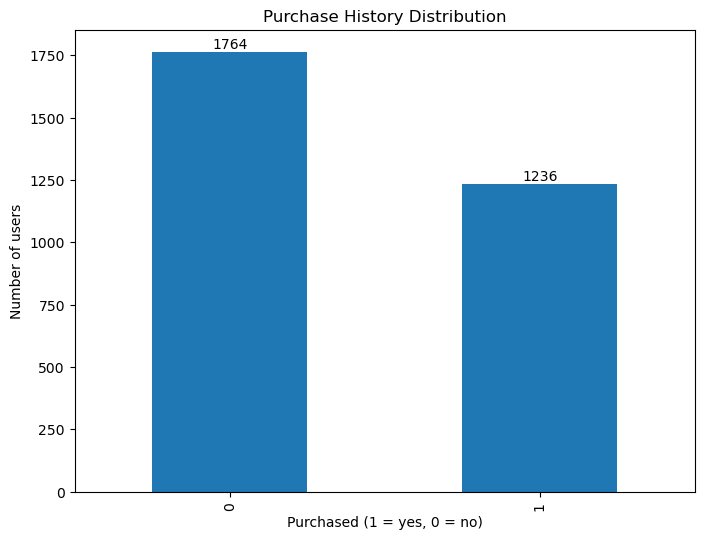

In [10]:
purchase_counts = df['purchased'].value_counts()      #purchase history for 3000 users
bg = purchase_counts.plot(kind = "bar", figsize = (8,6))

plt.title("Purchase History Distribution")
plt.xlabel("Purchased (1 = yes, 0 = no)")
plt.ylabel("Number of users")
bg.bar_label(bg.containers[0], label_type= 'edge')
plt.show()

In [11]:
grouping_df = df.groupby('region')['avg_monthly_spend'].mean().reset_index() #Here i aggregated by grouping...Mean avg_monthly_spend by each unique region
grouping_df = grouping_df.sort_values('avg_monthly_spend', ascending=False) #puts data in descending order from highest to lowest

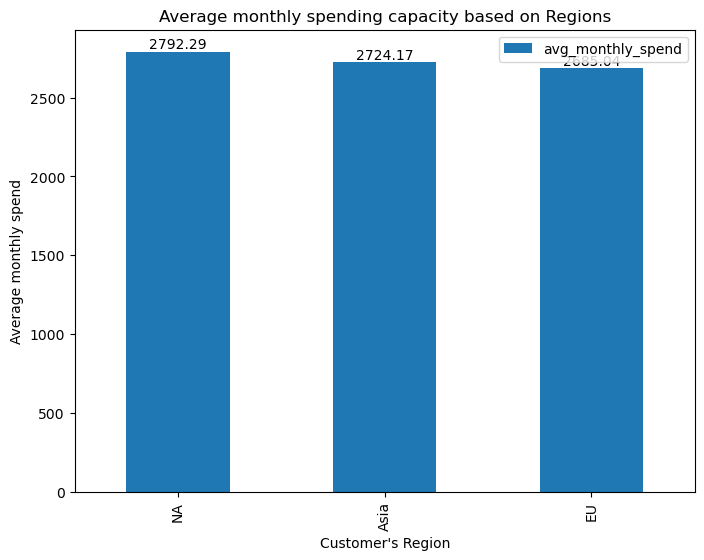

In [12]:
bg = grouping_df.plot(x="region", y="avg_monthly_spend", kind = "bar", figsize = (8,6)) #bg means bar graph 

bg.bar_label(bg.containers[0], label_type= 'edge')
plt.title("Average monthly spending capacity based on Regions")
plt.xlabel("Customer's Region")
plt.ylabel("Average monthly spend")
plt.show()

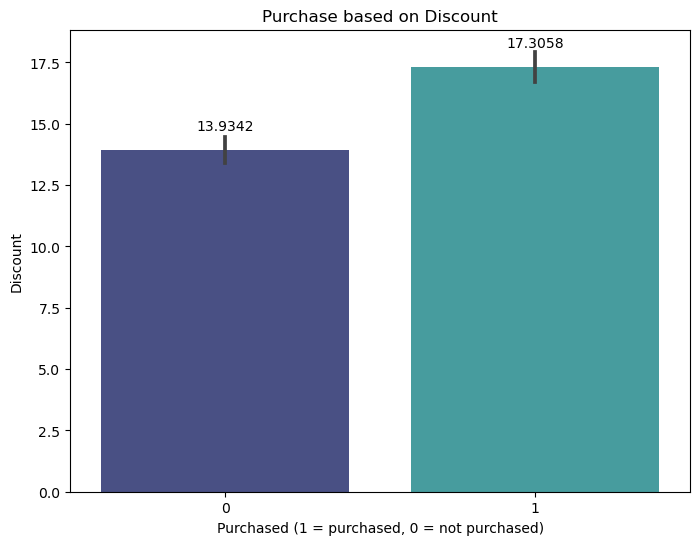

In [13]:
plt.figure(figsize = (8,6))
bg = sns.barplot(data = df, x = "purchased", y="discount_percent", palette= 'mako')

plt.title("Purchase based on Discount")
plt.xlabel("Purchased (1 = purchased, 0 = not purchased)")
plt.ylabel("Discount")
bg.bar_label(bg.containers[0], label_type= 'edge', padding= 12)  #labels the exact value of each bar graph
plt.show()

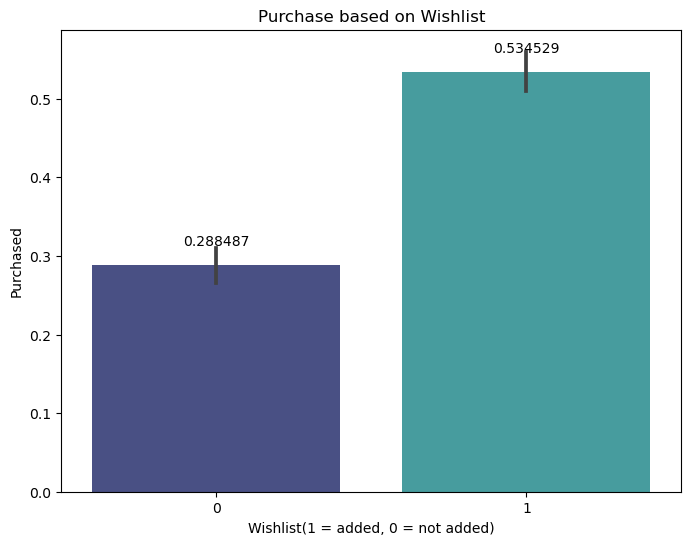

In [14]:
plt.figure(figsize = (8,6))
bg = sns.barplot(data = df, x ="wishlist_added", y= "purchased", palette= 'mako')

plt.title("Purchase based on Wishlist")
plt.xlabel("Wishlist(1 = added, 0 = not added)")
plt.ylabel("Purchased")
bg.bar_label(bg.containers[0], label_type= 'edge', padding= 12)  #labels the exact value of each bar graph
plt.show()

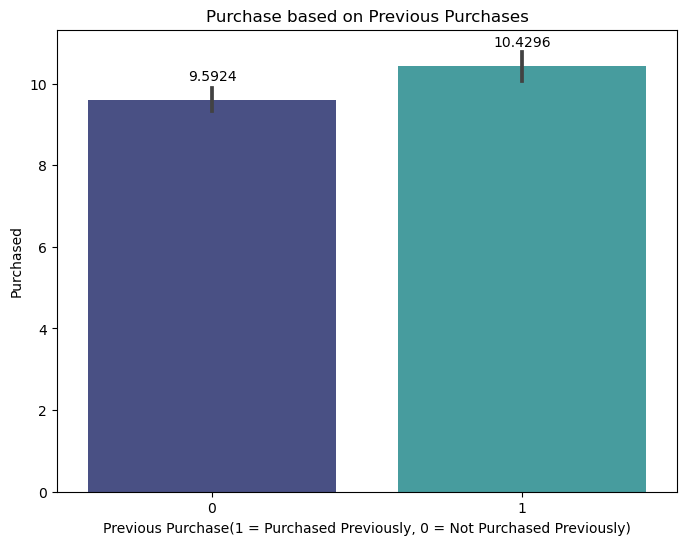

In [15]:
plt.figure(figsize = (8,6))
bg = sns.barplot(data = df, x ="purchased", y= "previous_purchases", palette= 'mako')

plt.title("Purchase based on Previous Purchases")
plt.xlabel("Previous Purchase(1 = Purchased Previously, 0 = Not Purchased Previously)")
plt.ylabel("Purchased")
bg.bar_label(bg.containers[0], label_type= 'edge', padding= 12)  #labels the exact value of each bar graph
plt.show()

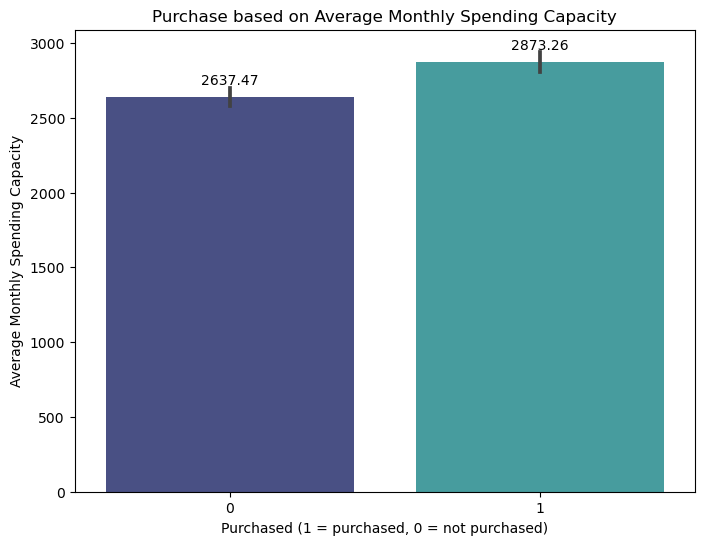

In [16]:
plt.figure(figsize = (8,6))
bg = sns.barplot(data = df, x = "purchased", y="avg_monthly_spend", palette= 'mako')

plt.title("Purchase based on Average Monthly Spending Capacity")
plt.xlabel("Purchased (1 = purchased, 0 = not purchased)")
plt.ylabel("Average Monthly Spending Capacity")
bg.bar_label(bg.containers[0], label_type= 'edge', padding= 7)  #labels the exact value of each bar graph
plt.show()

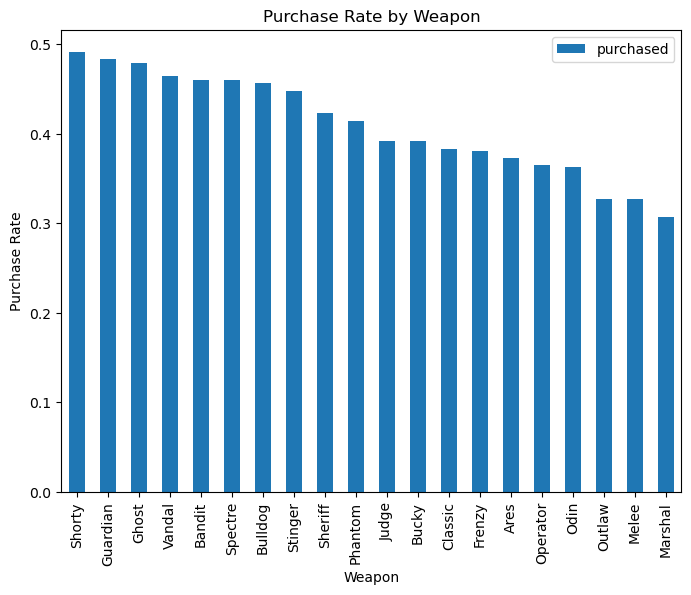

In [17]:
weapon_purchase = df.groupby('weapon_type')['purchased'].mean().reset_index() 
weapon_purchase = weapon_purchase.sort_values('purchased', ascending=False)

bg = weapon_purchase.plot(x="weapon_type", y="purchased", kind = "bar", figsize = (8,6)) 


plt.title("Purchase Rate by Weapon")
plt.xlabel("Weapon")
plt.ylabel("Purchase Rate")
plt.show()

NameError: name 'ax' is not defined

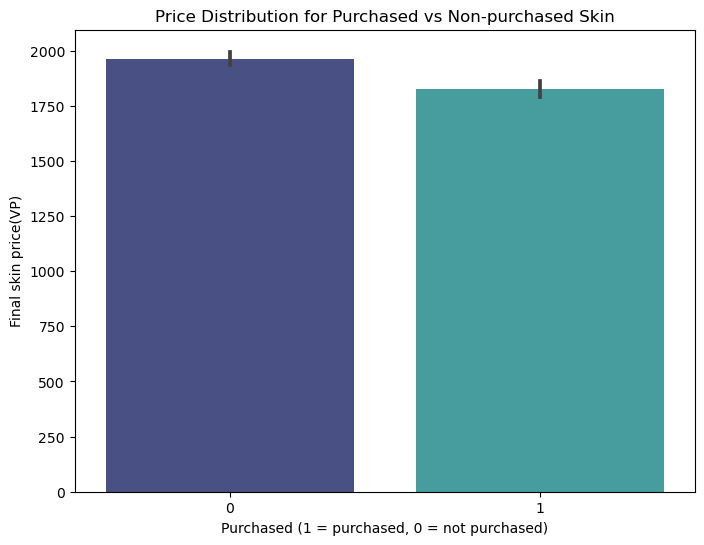

In [18]:
plt.figure(figsize = (8,6))
bg = sns.barplot(data = df, x = "purchased", y="final_price_vp", palette= 'mako')

plt.title("Price Distribution for Purchased vs Non-purchased Skin")
plt.xlabel("Purchased (1 = purchased, 0 = not purchased)")
plt.ylabel("Final skin price(VP)")
bg.bar_label(ax.containers[0], label_type= 'edge', padding= 6)  #labels the exact value of each bar graph
plt.show()

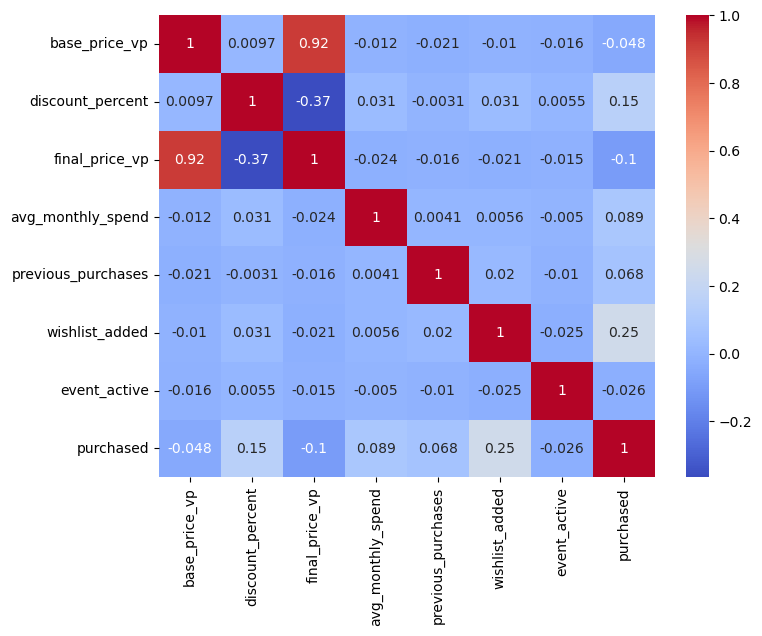

In [19]:
plt.figure(figsize=(8,6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm")  #shows correlation of every numerical columns
plt.show()

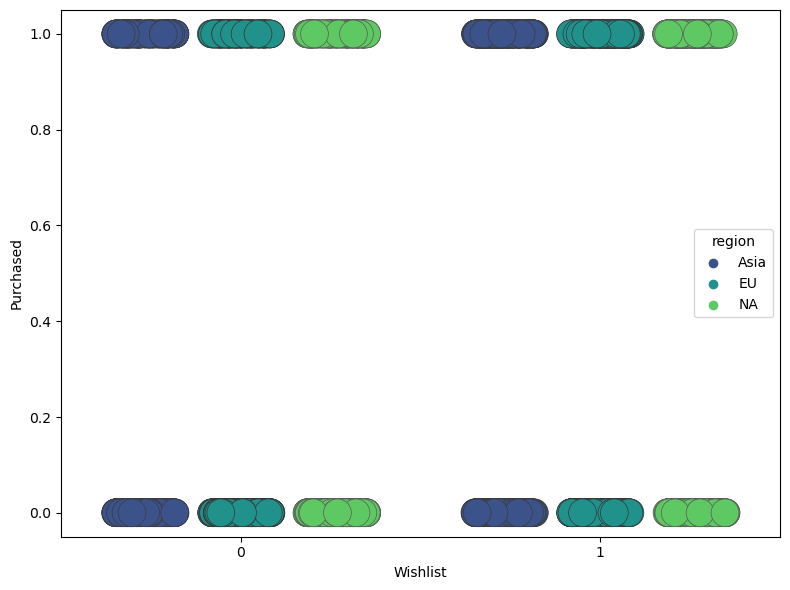

In [20]:
plt.figure(figsize=(8, 6))

sns.stripplot(            #scatter plot of wishlist_added and purchased
    data=df,
    x= 'wishlist_added',              #The top correlated variable
    y='purchased',
    hue='region',  #Colored by category 
    palette='viridis',
    jitter=0.25,
    dodge = True,
    linewidth=0.5,
    edgecolor='gray',
    s = 20)


plt.xlabel('Wishlist')
plt.ylabel('Purchased')
plt.tight_layout()
plt.show()

In [21]:
df.head()

,skin_name,weapon_type,base_price_vp,discount_percent,final_price_vp,region,rank,age_group,avg_monthly_spend,previous_purchases,wishlist_added,event_active,purchased
0,Glitchpop,Classic,2175,30,1522.5,Asia,Diamond,21-25,4470,19,0,1,0
1,Glitchpop,Classic,2175,20,1740.0,Asia,Platinum,26-30,2782,6,0,1,1
2,Overdrive,Stinger,2175,30,1522.5,EU,Diamond,16-20,2463,1,0,0,0
3,Araxys,Vandal,2175,0,2175.0,NA,Platinum,16-20,3094,9,1,1,1
4,Forsaken,Spectre,1775,20,1420.0,Asia,Radiant,21-25,2801,3,0,1,0


In [51]:
df_model = df.drop(columns= ["skin_name", "base_price_vp"], axis =1)

In [52]:
df_model.head()

,weapon_type,discount_percent,final_price_vp,region,rank,age_group,avg_monthly_spend,previous_purchases,wishlist_added,event_active,purchased
0,Classic,30,1522.5,Asia,Diamond,21-25,4470,19,0,1,0
1,Classic,20,1740.0,Asia,Platinum,26-30,2782,6,0,1,1
2,Stinger,30,1522.5,EU,Diamond,16-20,2463,1,0,0,0
3,Vandal,0,2175.0,NA,Platinum,16-20,3094,9,1,1,1
4,Spectre,20,1420.0,Asia,Radiant,21-25,2801,3,0,1,0


In [53]:
df_model = pd.get_dummies(df_model, drop_first=True)

In [54]:
X = df_model.drop("purchased", axis=1)
y = df_model["purchased"]

In [67]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size= 0.2, random_state= 42)

model = LogisticRegression(max_iter= 1000)
model.fit(X_train, y_train)
predictions = model.predict(X_test)

accuracy = accuracy_score(y_test, predictions)
print("Acurracy:", accuracy)

cm = confusion_matrix(y_test, predictions)
print("Confusion Matrix:", cm)

print(classification_report(y_test, predictions))


Acurracy: 0.63
Confusion Matrix: [[270 101]
 [121 108]]
              precision    recall  f1-score   support

           0       0.69      0.73      0.71       371
           1       0.52      0.47      0.49       229

    accuracy                           0.63       600
   macro avg       0.60      0.60      0.60       600
weighted avg       0.62      0.63      0.63       600



In [68]:
tree = DecisionTreeClassifier(max_depth=6, random_state=42)
tree.fit(X_train, y_train)
tree_pred = tree.predict(X_test)

print("Decision Tree Accuracy:", accuracy_score(y_test, tree_pred))

Decision Tree Accuracy: 0.625


In [69]:
rf = RandomForestClassifier(n_estimators=100, random_state=42)

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

print("Random Forest Accuracy:", accuracy_score(y_test, rf_pred))

Random Forest Accuracy: 0.6566666666666666
